# 🌀 One polymer, three experiments — Carreau fitting meets Cox–Merz and Rutgers–Delaware

*Steady shear says how a polymer solution flows; oscillation says how it relaxes. For a
high-molecular-weight linear polymer in water, the two stories should be the same story —
and with `rheofit` you can check, quantitatively, that they are.*

*Reproduces the [rheofit case study](https://rheofit.readthedocs.io/en/latest/walkthrough-carreau.html),
run live in JupyterLite.*

**Run each cell in order** (▶). The first cell installs `rheofit` in your browser — no server involved.

In [1]:
%pip install -q rheofit "rheopy-rheodata>=0.1.1"


Note: you may need to restart the kernel to use updated packages.


c:\Users\caggioni.m\rheolite\.venv\Scripts\python.exe: No module named pip


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import rheodata
import rheofit

rheofit_version = getattr(rheofit, "__version__", "installed")
rheodata_version = getattr(rheodata, "__version__", "installed")
print(f"rheofit {rheofit_version}")
print(f"rheodata {rheodata_version}")

rheofit 1.1.0
rheodata installed


## 🧪 The dataset

Equilibrium experiments on a **high-molecular-weight linear polymer
in aqueous solution** at **25 °C** — three experiments, all from the
[rheodata](https://github.com/rheopy/rheodata) library (v0.1.1+): the flow curve
(`caggioni_linear_polymer_flow`), the amplitude sweep
(`caggioni_linear_polymer_amplitude_sweep`) and the frequency sweep
(`caggioni_linear_polymer_frequency_sweep`). No file downloads needed.


In [13]:
flow_data = rheodata.to_rheofit(
    "caggioni_linear_polymer_flow",
    "linear_polymer",
)
amplitude_sweep_data = rheodata.load(
    "caggioni_linear_polymer_amplitude_sweep"
).df
frequency_sweep_data = rheodata.load(
    "caggioni_linear_polymer_frequency_sweep"
).df

print(
    f"Flow curve: {len(flow_data)} points | "
    f"amplitude sweep: {len(amplitude_sweep_data)} points | "
    f"frequency sweep: {len(frequency_sweep_data)} points"
)

Flow curve: 51 points | amplitude sweep: 41 points | frequency sweep: 31 points


## 📐 The Carreau model

The Carreau model describes a fluid with a **zero-shear plateau** that thins toward a
power law at high shear rates:

η(γ̇) = η₀ [1 + (λγ̇)²]^((n−1)/2)

Each parameter has a direct physical reading: **η₀** is the zero-shear viscosity of the
fully entangled network, **λ** is the characteristic relaxation time (thinning sets in at
γ̇_c = 1/λ), and **n** is the high-shear power-law exponent. Fitting the flow curve is
one line:


In [14]:
shear_rate = flow_data["Shear rate / 1/s"].to_numpy()
stress = flow_data["Stress / Pa"].to_numpy()
viscosity = stress / shear_rate

sort_order = np.argsort(shear_rate)
shear_rate_sorted = shear_rate[sort_order]
viscosity_sorted = viscosity[sort_order]

fit_result = rheofit.fit(flow_data, "carreau", effort="thorough", seed=0)
fit_parameters = {
    name: estimate["value"]
    for name, estimate in fit_result["params"].items()
}

print(
    f"RedChi2 = {fit_result['redchi']:.3e}, "
    f"condition number = {fit_result['cond']:.1f}"
)
for name, estimate in fit_result["params"].items():
    relative_uncertainty_pct = 100 * estimate["stderr"] / estimate["value"]
    print(
        f"{name:<12} = {estimate['value']:10.4g} "
        f"± {relative_uncertainty_pct:.1f}%"
    )

shear_rate_grid = np.logspace(-2, 3, 300)
fitted_viscosity = fit_parameters["eta_0"] * (
    1 + (fit_parameters["lambda_val"] * shear_rate_grid) ** 2
) ** ((fit_parameters["n"] - 1) / 2)
fitted_stress = fitted_viscosity * shear_rate_grid

RedChi2 = 3.847e-03, condition number = 9.5
eta_0        =      1.992 ± 1.3%
lambda_val   =     0.1992 ± 6.2%
n            =     0.4145 ± 2.3%


**Expect:** η₀ ≈ 1.99 Pa·s (±1.3 %), λ ≈ 0.199 s (±6.2 %), n ≈ 0.414 (±2.3 %),
RedChi² ≈ 3.85×10⁻³ — a clean, fully identified fit (condition number ≈ 9.5).


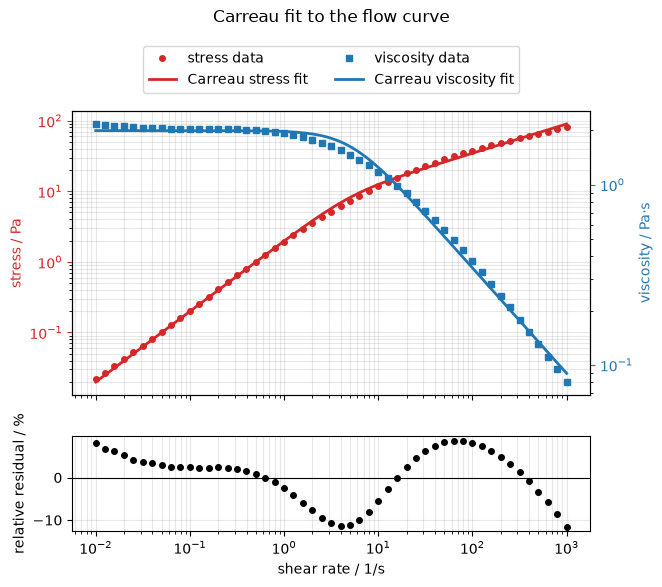

In [15]:
fig, (ax_stress, ax_residual) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(7, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)
ax_viscosity = ax_stress.twinx()

# Stress uses the left axis; viscosity uses the right axis.
stress_data, = ax_stress.loglog(
    shear_rate,
    stress,
    "o",
    color="tab:red",
    ms=4,
    label="stress data",
)
stress_fit, = ax_stress.loglog(
    shear_rate_grid,
    fitted_stress,
    "-",
    color="tab:red",
    lw=2,
    label="Carreau stress fit",
)
viscosity_data, = ax_viscosity.loglog(
    shear_rate,
    viscosity,
    "s",
    color="tab:blue",
    ms=4,
    label="viscosity data",
)
viscosity_fit, = ax_viscosity.loglog(
    shear_rate_grid,
    fitted_viscosity,
    "-",
    color="tab:blue",
    lw=2,
    label="Carreau viscosity fit",
)

ax_stress.set_ylabel("stress / Pa", color="tab:red")
ax_viscosity.set_ylabel("viscosity / Pa·s", color="tab:blue")
ax_stress.tick_params(axis="y", colors="tab:red")
ax_viscosity.tick_params(axis="y", colors="tab:blue")
ax_stress.grid(True, which="both", alpha=0.3)

fig.suptitle("Carreau fit to the flow curve", y=0.99)
fig.legend(
    handles=[stress_data, stress_fit, viscosity_data, viscosity_fit],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=2,
)
fig.subplots_adjust(left=0.13, right=0.87, top=0.82, bottom=0.12, hspace=0.22)

stress_fit_at_data = fit_parameters["eta_0"] * shear_rate * (
    1 + (fit_parameters["lambda_val"] * shear_rate) ** 2
) ** ((fit_parameters["n"] - 1) / 2)
relative_residual_pct = 100 * (stress - stress_fit_at_data) / stress

ax_residual.semilogx(shear_rate, relative_residual_pct, "ko", ms=4)
ax_residual.axhline(0, color="k", lw=0.8)
ax_residual.set_xlabel("shear rate / 1/s")
ax_residual.set_ylabel("relative residual / %")
ax_residual.grid(True, which="both", alpha=0.3)

plt.show()

The residuals show a mild S-shape (±10 %) — the honest signature of a real polymer
solution against the idealized Carreau form, not a fitting failure.

## 🔁 Cox–Merz: the frequency sweep predicts the flow curve

In 1958, Cox and Merz noticed something remarkable for polymer melts and solutions: the
**steady-shear viscosity equals the magnitude of the complex viscosity** when shear rate
and angular frequency are matched —

η(γ̇) = |η*(ω)| at ω = γ̇

— even though one is a nonlinear steady measurement and the other comes from small,
linear oscillations. No deep theory demanded it; the data did. With |η*| = √(G′²+G″²)/ω
from the frequency sweep:


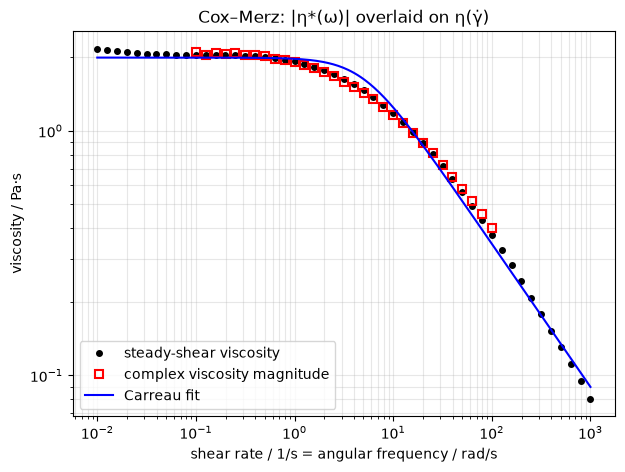

Cox–Merz agreement: 2.0% log-RMS over 0.1–100 s⁻¹


In [16]:
angular_frequency = frequency_sweep_data["omega_rad/s"].to_numpy()
storage_modulus = frequency_sweep_data["Gp_Pa"].to_numpy()
loss_modulus = frequency_sweep_data["Gpp_Pa"].to_numpy()
complex_viscosity = np.hypot(storage_modulus, loss_modulus) / angular_frequency

fig, ax_viscosity_comparison = plt.subplots(figsize=(7, 5))
ax_viscosity_comparison.loglog(
    shear_rate,
    viscosity,
    "ko",
    ms=4,
    label="steady-shear viscosity",
)
ax_viscosity_comparison.loglog(
    angular_frequency,
    complex_viscosity,
    "rs",
    mfc="none",
    mew=1.5,
    label="complex viscosity magnitude",
)
ax_viscosity_comparison.loglog(
    shear_rate_grid,
    fitted_viscosity,
    "b-",
    lw=1.5,
    label="Carreau fit",
)
ax_viscosity_comparison.set_xlabel("shear rate / 1/s = angular frequency / rad/s")
ax_viscosity_comparison.set_ylabel("viscosity / Pa·s")
ax_viscosity_comparison.set_title("Cox–Merz: |η*(ω)| overlaid on η(γ̇)")
ax_viscosity_comparison.legend()
ax_viscosity_comparison.grid(True, which="both", alpha=0.3)
plt.show()

comparison_mask = (angular_frequency >= 0.1) & (angular_frequency <= 100)
flow_viscosity_at_frequency = np.exp(
    np.interp(
        np.log(angular_frequency[comparison_mask]),
        np.log(shear_rate_sorted),
        np.log(viscosity_sorted),
    )
)
cox_merz_log_rms_pct = 100 * np.sqrt(
    np.mean(
        (
            np.log(flow_viscosity_at_frequency)
            - np.log(complex_viscosity[comparison_mask])
        ) ** 2
    )
)
print(
    f"Cox–Merz agreement: {cox_merz_log_rms_pct:.1f}% log-RMS "
    "over 0.1–100 s⁻¹"
)

The two curves coincide to within **≈2 % (log-RMS)** over three decades, 0.1–100 s⁻¹.
For this linear polymer solution, Cox–Merz holds essentially exactly — the small-amplitude
oscillatory measurement predicts the nonlinear flow curve with no adjustable parameters.

## 📊 Rutgers–Delaware: the amplitude sweep predicts the flow curve too

Doraiswamy and co-workers generalized Cox–Merz to *other* shear deformations: in a strain
sweep at fixed frequency, the **dynamic viscosity plotted against the strain-rate amplitude**
recovers the steady-shear viscosity —

η(γ̇) = η′(γ₀ω) at γ̇ = γ₀ω

— the **Rutgers–Delaware rule**. The amplitude sweep ran at ω = 1 rad/s, so γ₀ω spans
0.001–10 s⁻¹ — right across the Carreau plateau and into the thinning regime:

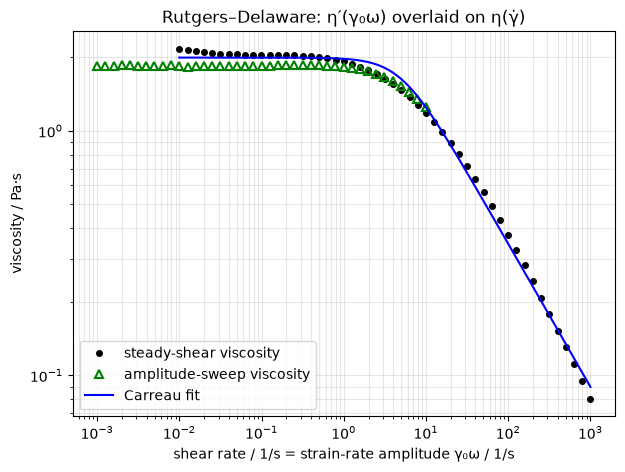

Rutgers–Delaware agreement: 9% log-RMS over the flow-sweep range


In [18]:
strain_amplitude = amplitude_sweep_data["strain_pct"].to_numpy() / 100
amplitude_sweep_frequency = 1.0
strain_rate_amplitude = strain_amplitude * amplitude_sweep_frequency
dynamic_viscosity = (
    amplitude_sweep_data["Gpp_Pa"].to_numpy() / amplitude_sweep_frequency
)

fig, ax_amplitude_comparison = plt.subplots(figsize=(7, 5))
ax_amplitude_comparison.loglog(
    shear_rate,
    viscosity,
    "ko",
    ms=4,
    label="steady-shear viscosity",
)
ax_amplitude_comparison.loglog(
    strain_rate_amplitude,
    dynamic_viscosity,
    "g^",
    mfc="none",
    mew=1.5,
    label="amplitude-sweep viscosity",
)
ax_amplitude_comparison.loglog(
    shear_rate_grid,
    fitted_viscosity,
    "b-",
    lw=1.5,
    label="Carreau fit",
)
ax_amplitude_comparison.set_xlabel(
    "shear rate / 1/s = strain-rate amplitude γ₀ω / 1/s"
)
ax_amplitude_comparison.set_ylabel("viscosity / Pa·s")
ax_amplitude_comparison.set_title(
    "Rutgers–Delaware: η′(γ₀ω) overlaid on η(γ̇)"
)
ax_amplitude_comparison.legend()
ax_amplitude_comparison.grid(True, which="both", alpha=0.3)
plt.show()

comparison_mask = (
    (strain_rate_amplitude >= shear_rate_sorted.min())
    & (strain_rate_amplitude <= shear_rate_sorted.max())
)
flow_viscosity_at_amplitude = np.exp(
    np.interp(
        np.log(strain_rate_amplitude[comparison_mask]),
        np.log(shear_rate_sorted),
        np.log(viscosity_sorted),
    )
)
rutgers_delaware_log_rms_pct = 100 * np.sqrt(
    np.mean(
        (
            np.log(flow_viscosity_at_amplitude)
            - np.log(dynamic_viscosity[comparison_mask])
        ) ** 2
    )
)
print(
    "Rutgers–Delaware agreement: "
    f"{rutgers_delaware_log_rms_pct:.0f}% log-RMS "
    "over the flow-sweep range"
)

Agreement within **≈9 % (log-RMS)**. The slight shortfall at the highest strain rates is
expected: beyond γ₀ ≈ 10–25 % the material leaves the linear regime and η′ begins its own
nonlinear descent.

## ✅ The LVE check: is the frequency sweep linear?

That the comparison is legitimate at all needs one check — the frequency sweep must sit
*inside* the linear viscoelastic regime. The amplitude sweep confirms it:


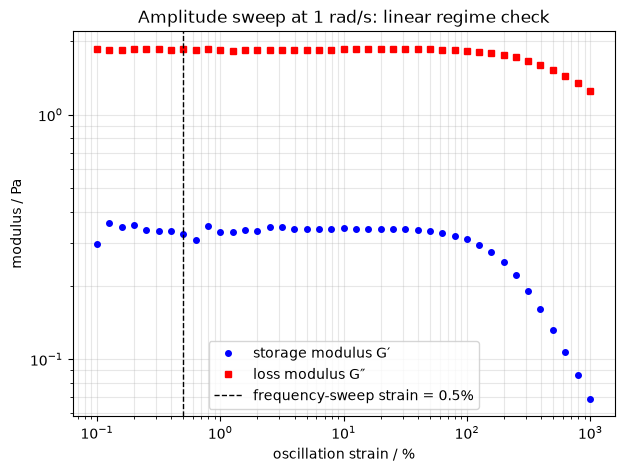

In [19]:
amplitude_strain_pct = amplitude_sweep_data["strain_pct"].to_numpy()
storage_modulus_amplitude = amplitude_sweep_data["Gp_Pa"].to_numpy()
loss_modulus_amplitude = amplitude_sweep_data["Gpp_Pa"].to_numpy()
frequency_sweep_strain_pct = 0.5

fig, ax_modulus = plt.subplots(figsize=(7, 5))
ax_modulus.loglog(
    amplitude_strain_pct,
    storage_modulus_amplitude,
    "bo",
    ms=4,
    label="storage modulus G′",
)
ax_modulus.loglog(
    amplitude_strain_pct,
    loss_modulus_amplitude,
    "rs",
    ms=4,
    label="loss modulus G″",
)
ax_modulus.axvline(
    frequency_sweep_strain_pct,
    color="k",
    ls="--",
    lw=1,
    label=f"frequency-sweep strain = {frequency_sweep_strain_pct:g}%",
)
ax_modulus.set_xlabel("oscillation strain / %")
ax_modulus.set_ylabel("modulus / Pa")
ax_modulus.set_title("Amplitude sweep at 1 rad/s: linear regime check")
ax_modulus.legend()
ax_modulus.grid(True, which="both", alpha=0.3)
plt.show()

G′ and G″ are strain-independent up to **γ₀ ≈ 10–25 %** — the linear plateau — so the
frequency sweep's γ = 0.5 % is safely linear. Above ≈25 % the moduli roll off: the network
starts yielding and η′ can no longer stand in for the steady-shear viscosity.

## 💡 Takeaways

- **One model, three experiments.** The Carreau fit (η₀ ≈ 1.99 Pa·s, λ ≈ 0.199 s,
  n ≈ 0.414) describes the flow curve; Cox–Merz (≈2.3 %) and Rutgers–Delaware (≈9 %) show
  the oscillatory experiments were measuring the same physics all along.
- **No adjustable parameters.** Both superposition rules are parameter-free predictions —
  when they hold this well, it is strong evidence the sample is a simple, well-behaved
  linear polymer solution with no thixotropy, slip, or degradation during the measurement.
- **Oscillation as a viscometer.** Where steady shear is hard — very low rates, very high
  rates, fragile samples — a frequency or amplitude sweep plus the right rule gives you the
  flow curve anyway.

*Full write-up: the [rheofit case study](https://rheofit.readthedocs.io/en/latest/walkthrough-carreau.html).*